In [1313]:
import pandas as pd

import numpy as np

import matplotlib.pyplot as plt

import seaborn as sb

from sklearn.metrics import accuracy_score

from sklearn.metrics import f1_score

from sklearn.metrics import confusion_matrix

from sklearn.metrics import roc_curve, roc_auc_score

from xgboost import XGBClassifier

from sklearn.linear_model import LogisticRegression

from sklearn.tree import DecisionTreeClassifier

from sklearn.ensemble import RandomForestClassifier

from sklearn.pipeline import make_pipeline

from sklearn.preprocessing import RobustScaler



In [1314]:
Train_90_path = "../Data/Train_test/train_90.csv"

Train_120_path = "../Data/Train_test/train_120.csv"

Train_150_path = "../Data/Train_test/train_150.csv"


# test


Test_90_path = "../Data/Train_test/test_90.csv"

Test_120_path = "../Data/Train_test/test_120.csv"

Test_150_path = "../Data/churn_test_dataset_150.csv"

In [1315]:
Data_train_90_df = pd.read_csv(Train_90_path)

Data_train_120_df = pd.read_csv(Train_120_path) 

Data_train_150_df = pd.read_csv(Train_150_path) 

Data_test_90_df = pd.read_csv(Test_90_path) 

Data_test_120_df = pd.read_csv(Test_120_path) 

Data_test_150_df = pd.read_csv(Test_150_path)  

-------
-------

## 90 days train_test dataset

In [1316]:
state_count = Data_train_90_df["customer_state"].value_counts()

state_count

customer_state
SP    3276
RJ    1217
MG    1048
RS     495
PR     457
SC     366
BA     301
ES     181
GO     176
PE     153
DF     151
CE     136
PA     107
MA      86
MT      79
AL      58
MS      57
PI      51
PB      51
SE      46
RN      44
TO      38
RO      31
AM      27
AC      14
RR       8
AP       8
Name: count, dtype: int64

In [1317]:
# Income
HIGH_INCOME = ["SP", "RJ", "AM", "SE"]
MID_INCOME = ["PI", "PB", "MS", "ES", "BA", "AL", "PE", "RN", "CE"]
LOW_INCOME = ["RR", "RO", "MT", "GO", "TO", "RS", "SC", "PR", "MA", "MG", "AC", "PA", "AP", "DF"]

prov_income_map = {
    **{i:"high" for i in HIGH_INCOME},
    **{i:"mid" for i in MID_INCOME},
    **{i:"low" for i in LOW_INCOME}
}
prov_income_map

{'SP': 'high',
 'RJ': 'high',
 'AM': 'high',
 'SE': 'high',
 'PI': 'mid',
 'PB': 'mid',
 'MS': 'mid',
 'ES': 'mid',
 'BA': 'mid',
 'AL': 'mid',
 'PE': 'mid',
 'RN': 'mid',
 'CE': 'mid',
 'RR': 'low',
 'RO': 'low',
 'MT': 'low',
 'GO': 'low',
 'TO': 'low',
 'RS': 'low',
 'SC': 'low',
 'PR': 'low',
 'MA': 'low',
 'MG': 'low',
 'AC': 'low',
 'PA': 'low',
 'AP': 'low',
 'DF': 'low'}

In [1318]:
Data_train_90_df["state_income_level"] = Data_train_90_df.customer_state.map(prov_income_map)

Data_train_90_df["state_income_level_high"] = (Data_train_90_df["state_income_level"] == "high").astype(int)
Data_train_90_df["state_income_level_mid"] = (Data_train_90_df["state_income_level"] == "mid").astype(int)
Data_train_90_df["state_income_level_low"] = (Data_train_90_df["state_income_level"] == "low").astype(int)

Data_train_90_df

,customer_unique_id,price,freight_to_price_ratio,payment_value,dates_diff,review_score,freight_to_weight_ratio,product_photos_qty,customer_city,customer_state,order_status,payment_sequential,payment_type,payment_installments,product_cat,churn_90,state_income_level,state_income_level_high,state_income_level_mid,state_income_level_low
0,0032c76b20340da25249092a268ce66c,128.90,0.124438,144.94,-27.0,4.0,0.002932,1.0,charqueada,SP,delivered,1.0,credit_card,1.0,entertainment,0,high,1,0,0
1,01f156677184504063bd19739f924af1,739.98,0.060569,784.80,-46.0,5.0,0.002873,2.0,gravatal,SC,delivered,1.0,credit_card,10.0,household,0,low,0,0,1
2,0313291a6f4f16df04dcf819d88c38ef,95.00,0.187158,112.78,0.0,1.0,0.017780,1.0,sao sebastiao,SP,processing,1.0,boleto,1.0,household,0,high,1,0,0
3,0636d30c77f0f9cfad81f1c9b58c791f,949.99,0.023127,971.96,-44.0,4.0,0.004674,2.0,itaquaquecetuba,SP,delivered,1.0,credit_card,10.0,entertainment,0,high,1,0,0
4,0659f2d6cabae94afd4d009c6d0e07dc,390.00,0.177282,918.28,0.0,1.0,0.003582,1.0,cacequi,RS,canceled,1.0,credit_card,4.0,automotive,0,low,0,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8657,ffe3e199b9d0b7fb7d2d29a5b9498447,146.90,0.103472,162.10,0.0,1.0,0.043429,2.0,uberlandia,MG,delivered,1.0,boleto,1.0,construction,0,low,0,0,1
8658,ffe4c3aa14d4702fb11fe5b3c4dd755c,118.90,0.154752,137.30,-15.0,5.0,0.013143,4.0,sarzedo,MG,delivered,1.0,credit_card,1.0,beauty,0,low,0,0,1
8659,ffedff0547d809c90c05c2691c51f9b7,17.90,0.811173,32.42,-56.0,5.0,0.064533,1.0,ribeirao preto,SP,delivered,1.0,credit_card,3.0,household,0,high,1,0,0
8660,ffef0ffa736c7b3d9af741611089729b,109.90,0.265423,139.07,-22.0,5.0,0.025678,1.0,nova venecia,ES,delivered,1.0,credit_card,1.0,sports_leisure,0,mid,0,1,0


In [1319]:


#Data_train_90_df["high_review_score"] = (Data_train_90_df["review_score"]>= 4).astype(int)
# Data_train_90_df["medium_review_score"] = ((Data_train_90_df["review_score"]< 4) & (Data_train_90_df["review_score"]>= 2)).astype(int)
#Data_train_90_df["low_review_score"] = (Data_train_90_df["review_score"]< 2).astype(int)

## Data_train_90_df


In [1321]:
# Data_train_90_df["delay"] = (Data_train_90_df["dates_diff"]>0).astype(int)

#Data_train_90_df["delay"]

In [1322]:
# Data_train_90_df["high_payment_value"] = (Data_train_90_df["payment_value"]>172.73).astype(int)

# Data_train_90_df["high_payment_value"]

In [1323]:
# One hot encoding for freight_price
# Data_train_90_df["expensive_freight"] = (Data_train_90_df["freight_to_price_ratio"]>0.15).astype(int)

# Data_train_90_df["expensive_freight"]

In [1324]:
# Data_train_90_df["high_freight_to_weight"] = (Data_train_90_df["freight_to_weight_ratio"]>0.20).astype(int)

# Data_train_90_df["high_freight_to_weight"]

In [1325]:
# One hot encoding for price

# Data_train_90_df["is_high_price"] = (Data_train_90_df["price"]>120.64).astype(int)

# Data_train_90_df["is_high_price"]

In [1326]:
# Data_train_90_df["beyond_one year"] = (Data_train_90_df["payment_installments"] > 12.0).astype(int)

# Data_train_90_df["beyond_one year"]

In [1327]:
# Data_train_90_df["multiple_payment_methods"] = (Data_train_90_df["payment_sequential"] > 2.0).astype(int)

# ata_train_90_df["multiple_payment_methods"]

In [1328]:
# Data_train_90_df["low_foto_count"] = (Data_train_90_df["product_photos_qty"] < 2).astype(int)

# Data_train_90_df["low_foto_count"]

In [1329]:
from sklearn.compose import ColumnTransformer

from sklearn.preprocessing import OneHotEncoder

In [1330]:
# Create one hot encoding for all non-int features  Logprices?

target_features = ["order_status", "payment_type", "product_cat"]

col_trans = ColumnTransformer(
    transformers=[("cat", OneHotEncoder(sparse_output= False, drop="first", handle_unknown="ignore"), target_features)], remainder="passthrough"
)
col_trans.fit(Data_train_90_df)

,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'passthrough'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains sparse matrices,these will be stacked as a sparse matrix if the overall density islower than this value. Use ``sparse_threshold=0`` to always returndense. When the transformed output consists of all dense data, thestacked result will be dense, and this keyword will be ignored.",0.3
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details.",None
,"transformer_weights transformer_weights: dict, default=NoneMultiplicative weights for features per transformer. The output of thetransformer is multiplied by these weights. Keys are transformer names,values the weights.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each transformer will beprinted as it is completed.",False
,"verbose_feature_names_out verbose_feature_names_out: bool, str or Callable[[str, str], str], default=True- If True, :meth:`ColumnTransformer.get_feature_names_out` will prefix all feature names with the name of the transformer that generated that feature. It is equivalent to setting `verbose_feature_names_out=""{transformer_name}__{feature_name}""`.- If False, :meth:`ColumnTransformer.get_feature_names_out` will not prefix any feature names and will error if feature names are not unique.- If ``Callable[[str, str], str]``, :meth:`ColumnTransformer.get_feature_names_out` will rename all the features using the name of the transformer. The first argument of the callable is the transformer name and the second argument is the feature name. The returned string will be the new feature name.- If ``str``, it must be a string ready for formatting. The given string will be formatted using two field names: ``transformer_name`` and ``feature_name``. e.g. 

In [1331]:
# fit and transform the dataset

encoded_array = col_trans.transform(Data_train_90_df)

In [1332]:
feature_names = col_trans.get_feature_names_out(Data_train_90_df.columns)
encoded_90_df = pd.DataFrame(encoded_array, columns= feature_names)

encoded_90_df

,cat__order_status_canceled,cat__order_status_delivered,cat__order_status_invoiced,cat__order_status_processing,cat__order_status_shipped,cat__order_status_unavailable,cat__payment_type_credit_card,cat__payment_type_debit_card,cat__payment_type_voucher,cat__product_cat_babies,...,remainder__product_photos_qty,remainder__customer_city,remainder__customer_state,remainder__payment_sequential,remainder__payment_installments,remainder__churn_90,remainder__state_income_level,remainder__state_income_level_high,remainder__state_income_level_mid,remainder__state_income_level_low
0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,...,1.0,charqueada,SP,1.0,1.0,0,high,1,0,0
1,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,...,2.0,gravatal,SC,1.0,10.0,0,low,0,0,1
2,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,...,1.0,sao sebastiao,SP,1.0,1.0,0,high,1,0,0
3,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,...,2.0,itaquaquecetuba,SP,1.0,10.0,0,high,1,0,0
4,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,...,1.0,cacequi,RS,1.0,4.0,0,low,0,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8657,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,2.0,uberlandia,MG,1.0,1.0,0,low,0,0,1
8658,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,...,4.0,sarzedo,MG,1.0,1.0,0,low,0,0,1
8659,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,...,1.0,ribeirao preto,SP,1.0,3.0,0,high,1,0,0
8660,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,...,1.0,nova venecia,ES,1.0,1.0,0,mid,0,1,0


In [1333]:
encoded_90_df.columns = encoded_90_df.columns.str.replace('remainder__', '')

encoded_90_df

,cat__order_status_canceled,cat__order_status_delivered,cat__order_status_invoiced,cat__order_status_processing,cat__order_status_shipped,cat__order_status_unavailable,cat__payment_type_credit_card,cat__payment_type_debit_card,cat__payment_type_voucher,cat__product_cat_babies,...,product_photos_qty,customer_city,customer_state,payment_sequential,payment_installments,churn_90,state_income_level,state_income_level_high,state_income_level_mid,state_income_level_low
0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,...,1.0,charqueada,SP,1.0,1.0,0,high,1,0,0
1,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,...,2.0,gravatal,SC,1.0,10.0,0,low,0,0,1
2,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,...,1.0,sao sebastiao,SP,1.0,1.0,0,high,1,0,0
3,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,...,2.0,itaquaquecetuba,SP,1.0,10.0,0,high,1,0,0
4,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,...,1.0,cacequi,RS,1.0,4.0,0,low,0,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8657,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,2.0,uberlandia,MG,1.0,1.0,0,low,0,0,1
8658,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,...,4.0,sarzedo,MG,1.0,1.0,0,low,0,0,1
8659,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,...,1.0,ribeirao preto,SP,1.0,3.0,0,high,1,0,0
8660,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,...,1.0,nova venecia,ES,1.0,1.0,0,mid,0,1,0


beyond one tear= the payment takes more than one year

-----

# Test dataset

In [1334]:
Data_test_90_df

,customer_unique_id,price,freight_to_price_ratio,payment_value,dates_diff,review_score,freight_to_weight_ratio,product_photos_qty,customer_city,customer_state,order_status,payment_sequential,payment_type,payment_installments,product_cat,churn_90
0,00053a61a98854899e70ed204dd4bafe,382.00,0.097330,838.36,-10.0,1.0,0.016423,1.0,curitiba,PR,delivered,1.0,credit_card,3.0,sports_leisure,0
1,000c8bdb58a29e7115cfc257230fb21b,13.90,1.086331,29.00,-9.0,5.0,0.086286,2.0,belo horizonte,MG,delivered,1.0,credit_card,2.0,household,0
2,000d460961d6dbfa3ec6c9f5805769e1,28.90,0.269204,36.68,-13.0,5.0,0.051867,3.0,sao paulo,SP,delivered,1.0,credit_card,1.0,electronics,0
3,0014a5a58da615f7b01a4f5e194bf5ea,88.00,0.134318,99.82,-7.0,5.0,0.021491,2.0,sao paulo,SP,delivered,1.0,credit_card,3.0,beauty,0
4,00196fdb2bf9edfc35e88ebfbcf8d781,12.90,1.093023,27.00,1.0,3.0,0.080571,1.0,canoas,RS,delivered,1.0,credit_card,1.0,electronics,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
39545,ffecceca389973ef16660d58696f281e,59.90,0.214691,72.76,-15.0,5.0,0.064300,1.0,ilha solteira,SP,delivered,1.0,boleto,1.0,fashion,0
39546,ffeddf8aa7cdecf403e77b2e9a99e2ea,330.00,0.237576,204.20,6.0,2.0,0.174222,3.0,santarem,PA,delivered,2.0,credit_card,5.0,office,0
39547,fff2ae16b99c6f3c785f0e052f2a9cfb,129.94,0.546098,200.90,-21.0,5.0,0.005117,1.0,rio de janeiro,RJ,delivered,1.0,credit_card,8.0,office,0
39548,fffcc512b7dfecaffd80f13614af1d16,688.00,0.032994,710.70,0.0,1.0,0.026182,2.0,cabo frio,RJ,shipped,1.0,credit_card,3.0,beauty,0


In [1335]:
Data_test_90_df["state_income_level"] = Data_test_90_df.customer_state.map(prov_income_map)

Data_test_90_df["state_income_level_high"] = (Data_test_90_df["state_income_level"] == "high").astype(int)
Data_test_90_df["state_income_level_mid"] = (Data_test_90_df["state_income_level"] == "mid").astype(int)
Data_test_90_df["state_income_level_low"] = (Data_test_90_df["state_income_level"] == "low").astype(int)

Data_test_90_df 

,customer_unique_id,price,freight_to_price_ratio,payment_value,dates_diff,review_score,freight_to_weight_ratio,product_photos_qty,customer_city,customer_state,order_status,payment_sequential,payment_type,payment_installments,product_cat,churn_90,state_income_level,state_income_level_high,state_income_level_mid,state_income_level_low
0,00053a61a98854899e70ed204dd4bafe,382.00,0.097330,838.36,-10.0,1.0,0.016423,1.0,curitiba,PR,delivered,1.0,credit_card,3.0,sports_leisure,0,low,0,0,1
1,000c8bdb58a29e7115cfc257230fb21b,13.90,1.086331,29.00,-9.0,5.0,0.086286,2.0,belo horizonte,MG,delivered,1.0,credit_card,2.0,household,0,low,0,0,1
2,000d460961d6dbfa3ec6c9f5805769e1,28.90,0.269204,36.68,-13.0,5.0,0.051867,3.0,sao paulo,SP,delivered,1.0,credit_card,1.0,electronics,0,high,1,0,0
3,0014a5a58da615f7b01a4f5e194bf5ea,88.00,0.134318,99.82,-7.0,5.0,0.021491,2.0,sao paulo,SP,delivered,1.0,credit_card,3.0,beauty,0,high,1,0,0
4,00196fdb2bf9edfc35e88ebfbcf8d781,12.90,1.093023,27.00,1.0,3.0,0.080571,1.0,canoas,RS,delivered,1.0,credit_card,1.0,electronics,0,low,0,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
39545,ffecceca389973ef16660d58696f281e,59.90,0.214691,72.76,-15.0,5.0,0.064300,1.0,ilha solteira,SP,delivered,1.0,boleto,1.0,fashion,0,high,1,0,0
39546,ffeddf8aa7cdecf403e77b2e9a99e2ea,330.00,0.237576,204.20,6.0,2.0,0.174222,3.0,santarem,PA,delivered,2.0,credit_card,5.0,office,0,low,0,0,1
39547,fff2ae16b99c6f3c785f0e052f2a9cfb,129.94,0.546098,200.90,-21.0,5.0,0.005117,1.0,rio de janeiro,RJ,delivered,1.0,credit_card,8.0,office,0,high,1,0,0
39548,fffcc512b7dfecaffd80f13614af1d16,688.00,0.032994,710.70,0.0,1.0,0.026182,2.0,cabo frio,RJ,shipped,1.0,credit_card,3.0,beauty,0,high,1,0,0


In [1336]:
#Data_test_90_df["high_review_score"] = (Data_test_90_df["review_score"]>= 4).astype(int)
#Data_test_90_df["medium_review_score"] = ((Data_test_90_df["review_score"]< 4) & (Data_test_90_df["review_score"]>= 2)).astype(int)
#Data_test_90_df["low_review_score"] = (Data_test_90_df["review_score"]< 2).astype(int)

#Data_test_90_df

In [1337]:
#Data_test_90_df["delay"] = (Data_test_90_df["dates_diff"]>0).astype(int)

#Data_test_90_df["delay"]

In [1338]:
# Data_test_90_df["high_payment_value"] = (Data_test_90_df["payment_value"]>172.73).astype(int)

# Data_test_90_df["high_payment_value"]

In [1339]:
#Data_test_90_df["expensive_freight"] = (Data_test_90_df["freight_to_price_ratio"]>0.15).astype(int)

#Data_test_90_df["expensive_freight"]

In [1340]:
#Data_test_90_df["high_freight_to_weight"] = (Data_test_90_df["freight_to_weight_ratio"]>0.20).astype(int)

#Data_test_90_df["high_freight_to_weight"]

In [1341]:
# Data_test_90_df["is_high_price"] = (Data_test_90_df["price"]>120.64).astype(int)

# Data_test_90_df["is_high_price"]

In [1342]:
#Data_test_90_df["beyond_one year"] = (Data_test_90_df["payment_installments"] > 12.0).astype(int)

#Data_test_90_df["beyond_one year"]

In [1343]:
#Data_test_90_df["multiple_payment_methods"] = (Data_test_90_df["payment_sequential"] > 2.0).astype(int)

#Data_test_90_df["multiple_payment_methods"]

In [1344]:
# Data_test_90_df["low_foto_count"] = (Data_test_90_df["product_photos_qty"] < 2).astype(int)

# Data_test_90_df["low_foto_count"]

In [1345]:
Data_train_90_df["order_status"].value_counts()

order_status
delivered      8331
shipped         150
canceled         70
processing       55
invoiced         49
unavailable       6
approved          1
Name: count, dtype: int64

In [1346]:
Data_test_90_df["order_status"].value_counts()

order_status
delivered     38739
shipped         464
canceled        160
invoiced         95
processing       92
Name: count, dtype: int64

In [1347]:
target_features = ["order_status", "payment_type", "product_cat"]



In [1348]:
encoded_array_test = col_trans.transform(Data_test_90_df)

In [1349]:
Data_test_90_df.columns

Index(['customer_unique_id', 'price', 'freight_to_price_ratio',
       'payment_value', 'dates_diff', 'review_score',
       'freight_to_weight_ratio', 'product_photos_qty', 'customer_city',
       'customer_state', 'order_status', 'payment_sequential', 'payment_type',
       'payment_installments', 'product_cat', 'churn_90', 'state_income_level',
       'state_income_level_high', 'state_income_level_mid',
       'state_income_level_low'],
      dtype='str')

In [1350]:
Data_test_90_df.columns

Index(['customer_unique_id', 'price', 'freight_to_price_ratio',
       'payment_value', 'dates_diff', 'review_score',
       'freight_to_weight_ratio', 'product_photos_qty', 'customer_city',
       'customer_state', 'order_status', 'payment_sequential', 'payment_type',
       'payment_installments', 'product_cat', 'churn_90', 'state_income_level',
       'state_income_level_high', 'state_income_level_mid',
       'state_income_level_low'],
      dtype='str')

In [1351]:
encoded_90_test_df = pd.DataFrame(encoded_array, columns= col_trans.get_feature_names_out(Data_test_90_df.columns))

encoded_90_test_df

,cat__order_status_canceled,cat__order_status_delivered,cat__order_status_invoiced,cat__order_status_processing,cat__order_status_shipped,cat__order_status_unavailable,cat__payment_type_credit_card,cat__payment_type_debit_card,cat__payment_type_voucher,cat__product_cat_babies,...,remainder__product_photos_qty,remainder__customer_city,remainder__customer_state,remainder__payment_sequential,remainder__payment_installments,remainder__churn_90,remainder__state_income_level,remainder__state_income_level_high,remainder__state_income_level_mid,remainder__state_income_level_low
0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,...,1.0,charqueada,SP,1.0,1.0,0,high,1,0,0
1,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,...,2.0,gravatal,SC,1.0,10.0,0,low,0,0,1
2,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,...,1.0,sao sebastiao,SP,1.0,1.0,0,high,1,0,0
3,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,...,2.0,itaquaquecetuba,SP,1.0,10.0,0,high,1,0,0
4,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,...,1.0,cacequi,RS,1.0,4.0,0,low,0,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8657,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,2.0,uberlandia,MG,1.0,1.0,0,low,0,0,1
8658,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,...,4.0,sarzedo,MG,1.0,1.0,0,low,0,0,1
8659,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,...,1.0,ribeirao preto,SP,1.0,3.0,0,high,1,0,0
8660,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,...,1.0,nova venecia,ES,1.0,1.0,0,mid,0,1,0


In [1352]:
encoded_90_test_df.columns = encoded_90_test_df.columns.str.replace('remainder__', '')

encoded_90_test_df

,cat__order_status_canceled,cat__order_status_delivered,cat__order_status_invoiced,cat__order_status_processing,cat__order_status_shipped,cat__order_status_unavailable,cat__payment_type_credit_card,cat__payment_type_debit_card,cat__payment_type_voucher,cat__product_cat_babies,...,product_photos_qty,customer_city,customer_state,payment_sequential,payment_installments,churn_90,state_income_level,state_income_level_high,state_income_level_mid,state_income_level_low
0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,...,1.0,charqueada,SP,1.0,1.0,0,high,1,0,0
1,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,...,2.0,gravatal,SC,1.0,10.0,0,low,0,0,1
2,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,...,1.0,sao sebastiao,SP,1.0,1.0,0,high,1,0,0
3,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,...,2.0,itaquaquecetuba,SP,1.0,10.0,0,high,1,0,0
4,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,...,1.0,cacequi,RS,1.0,4.0,0,low,0,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8657,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,2.0,uberlandia,MG,1.0,1.0,0,low,0,0,1
8658,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,...,4.0,sarzedo,MG,1.0,1.0,0,low,0,0,1
8659,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,...,1.0,ribeirao preto,SP,1.0,3.0,0,high,1,0,0
8660,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,...,1.0,nova venecia,ES,1.0,1.0,0,mid,0,1,0


In [1353]:
Data_test_90_df["churn_90"].value_counts()

churn_90
0    39201
1      349
Name: count, dtype: int64

--------

In [1354]:
encoded_90_df["customer_unique_id"]

0       0032c76b20340da25249092a268ce66c
1       01f156677184504063bd19739f924af1
2       0313291a6f4f16df04dcf819d88c38ef
3       0636d30c77f0f9cfad81f1c9b58c791f
4       0659f2d6cabae94afd4d009c6d0e07dc
                      ...               
8657    ffe3e199b9d0b7fb7d2d29a5b9498447
8658    ffe4c3aa14d4702fb11fe5b3c4dd755c
8659    ffedff0547d809c90c05c2691c51f9b7
8660    ffef0ffa736c7b3d9af741611089729b
8661    ffffd2657e2aad2907e67c3e9daecbeb
Name: customer_unique_id, Length: 8662, dtype: str

# Train test split

In [1355]:
X_train = encoded_90_df.drop(columns = ['churn_90', "customer_unique_id", "customer_city", "customer_state", "state_income_level"])

y_train = encoded_90_df['churn_90'].fillna(0).astype(int)

In [1356]:
X_valtest = encoded_90_test_df.drop(columns = ['churn_90', "customer_unique_id", "customer_city", "customer_state", "state_income_level"])

y_valtest = encoded_90_test_df['churn_90'].fillna(0).astype(int)

In [1357]:
encoded_90_df.dtypes.value_counts()

object    37
str        4
Name: count, dtype: int64

In [1358]:
X_train = X_train.astype(int)


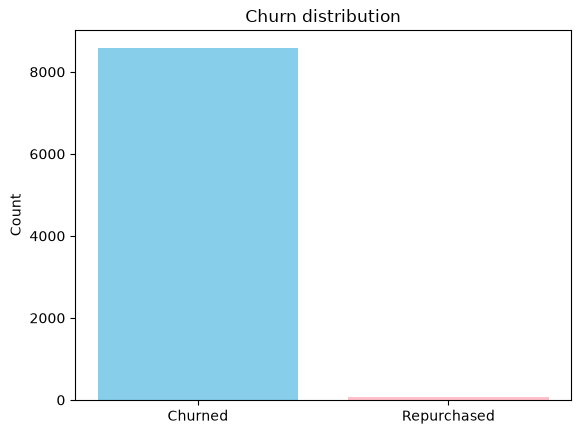

In [1359]:

plt.bar(y_train.value_counts().index, y_train.value_counts().values, color=['skyblue','pink'])
plt.xticks([0,1], ["Churned", "Repurchased"])
plt.ylabel("Count")
plt.title("Churn distribution")
plt.show()

In [1360]:
y_train

0       0
1       0
2       0
3       0
4       0
       ..
8657    0
8658    0
8659    0
8660    0
8661    0
Name: churn_90, Length: 8662, dtype: int64

In [1361]:
from sklearn.model_selection import train_test_split

X_val, X_test, y_val, y_test  =  train_test_split(X_valtest, y_valtest, random_state = 42)
X_val = X_val.astype(int)
X_test = X_test.astype(int)

In [1362]:
print(X_train.shape)
print(X_valtest.shape)

(8662, 36)
(8662, 36)


In [1363]:
my_experiment_list = [
    {
        "name":"DT - gini",
        "clf":DecisionTreeClassifier,
        "params": {
            "criterion": "gini",
            "max_depth": 5000,
            "random_state": 42
        }
    },
    {
        "name":"DT - entropy",
        "clf":DecisionTreeClassifier,
        "params": {
            "criterion": "entropy",
            "max_depth": 5000,
            "random_state": 42
        }
    },
    {
        "name":"RF - gini_50",
        "clf":RandomForestClassifier,
        "params": {
            "criterion": "gini",
            "n_estimators": 50,
            "max_features": "sqrt",
            "random_state": 42,
            "n_jobs":-1
        }
    },
    {
        "name":"RF - gini_100",
        "clf":RandomForestClassifier,
        "params": {
            "criterion": "gini",
            "n_estimators": 100,
            "max_features": "sqrt",
            "random_state": 42,
            "n_jobs":-1
        }
    },
    {
        "name":"RF - gini_300",
        "clf":RandomForestClassifier,
        "params": {
            "criterion": "entropy",
            "n_estimators": 300,
            "max_features": "sqrt",
            "random_state": 42,
            "n_jobs":-1
        }
    },
    {
        "name":"LogReg",
        "clf":lambda **params: make_pipeline(RobustScaler(), LogisticRegression(**params)),
        "params": {
            "random_state": 42,
            "penalty": "l2",
            "C": 1.0
        }
    },
    {
        "name":"XGBoost - ",
        "clf":XGBClassifier,
        "params": {
            'objective':'binary:logistic',
            'max_depth': 20,
            'alpha': 10,
            'learning_rate': 1.0,
            'n_estimators':100
        }
    },
]

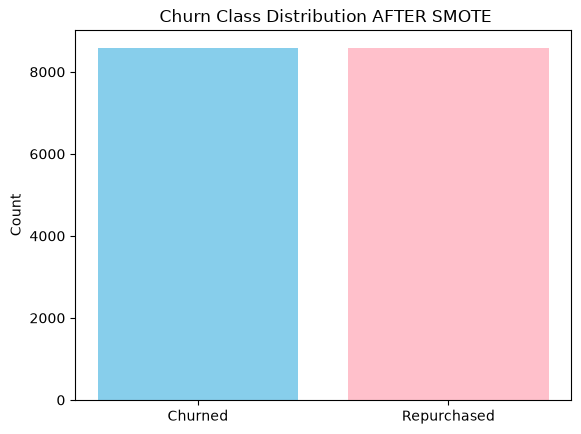

In [1364]:
from imblearn.over_sampling import SMOTE

smote = SMOTE(sampling_strategy="minority", random_state=42)
X_train_sm, y_train_sm = smote.fit_resample(X_train, y_train)

plt.bar(y_train_sm.value_counts().index, y_train_sm.value_counts().values, 
        color=["skyblue","pink"])
plt.xticks([0,1], ["Churned", "Repurchased"])
plt.ylabel("Count")
plt.title(" Churn Class Distribution AFTER SMOTE")
plt.show()

-----

In [1365]:
def plot_auc(y_test, y_pred_proba):
    fpr, tpr, thresholds = roc_curve(y_test, y_pred_proba)

    # 3. Calculate AUC Score
    auc_score = roc_auc_score(y_test, y_pred_proba)

    # 4. Plot the ROC Curve
    plt.figure(figsize=(8, 6))
    plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (AUC = {auc_score:.4f})')
    plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--', label='Random Chance')

    # Formatting details
    plt.xlim([0.0, 1.0])
    plt.ylim([0.0, 1.05])
    plt.xlabel('False Positive Rate (1 - Specificity)')
    plt.ylabel('True Positive Rate (Sensitivity / Recall)')
    plt.title('Receiver Operating Characteristic (ROC) Curve')
    plt.legend(loc="lower right")
    plt.grid(alpha=0.3)
    plt.show()
    return auc_score

In [ ]:
a = clf.predict_proba(ds_x)

a[:, 1]>= 0.8

------------------------------------
DT - gini
------------------------------------


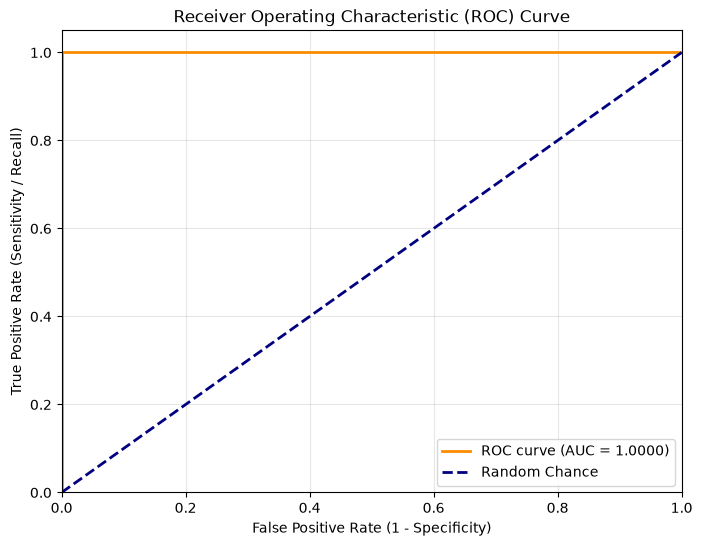

-----  Trainsm  -----
Model F1 score: 1.0000
Model accuracy: 1.0000
[[8583    0]
 [   0 8583]]



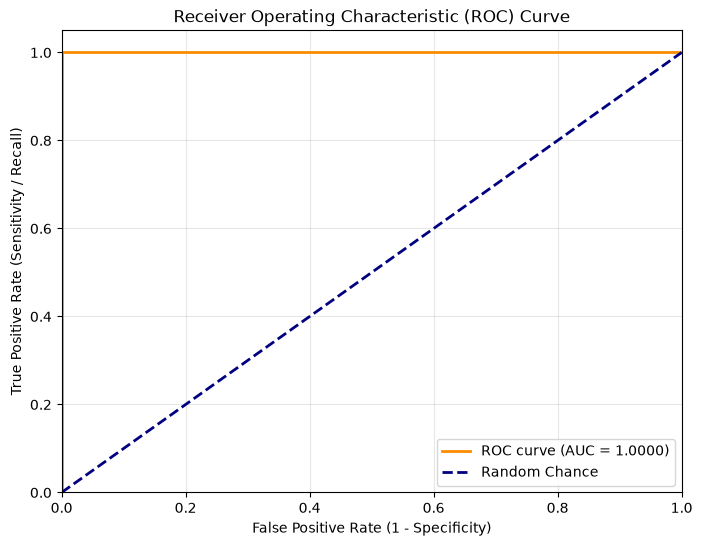

-----  Train  -----
Model F1 score: 1.0000
Model accuracy: 1.0000
[[8583    0]
 [   0   79]]



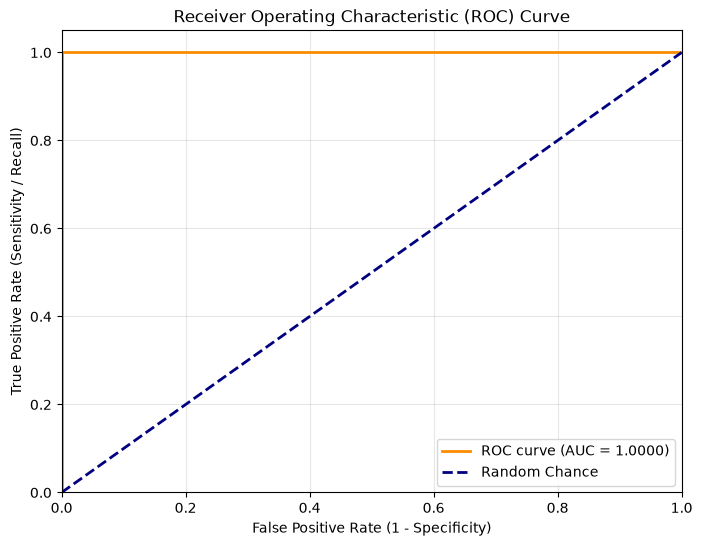

-----  Val  -----
Model F1 score: 1.0000
Model accuracy: 1.0000
[[6436    0]
 [   0   60]]



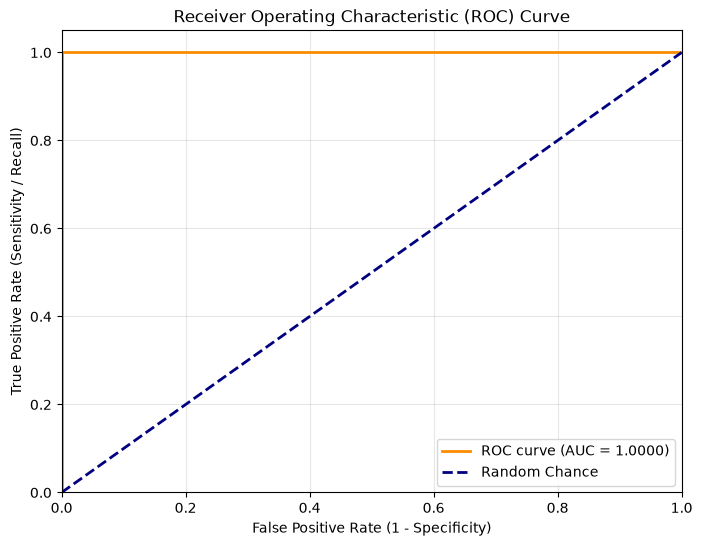

-----  Test  -----
Model F1 score: 1.0000
Model accuracy: 1.0000
[[2147    0]
 [   0   19]]

------------------------------------


------------------------------------
DT - entropy
------------------------------------


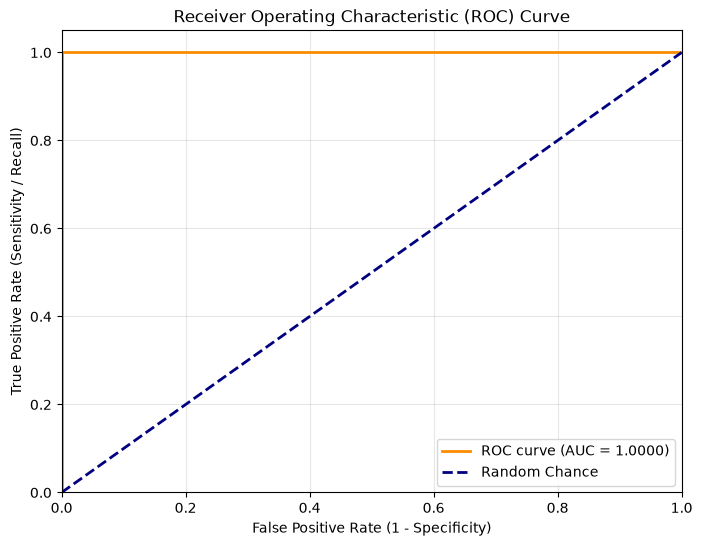

-----  Trainsm  -----
Model F1 score: 1.0000
Model accuracy: 1.0000
[[8583    0]
 [   0 8583]]



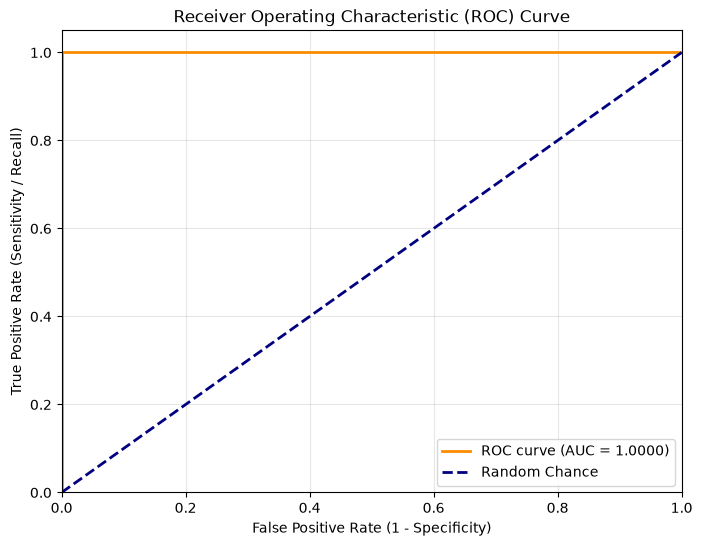

-----  Train  -----
Model F1 score: 1.0000
Model accuracy: 1.0000
[[8583    0]
 [   0   79]]



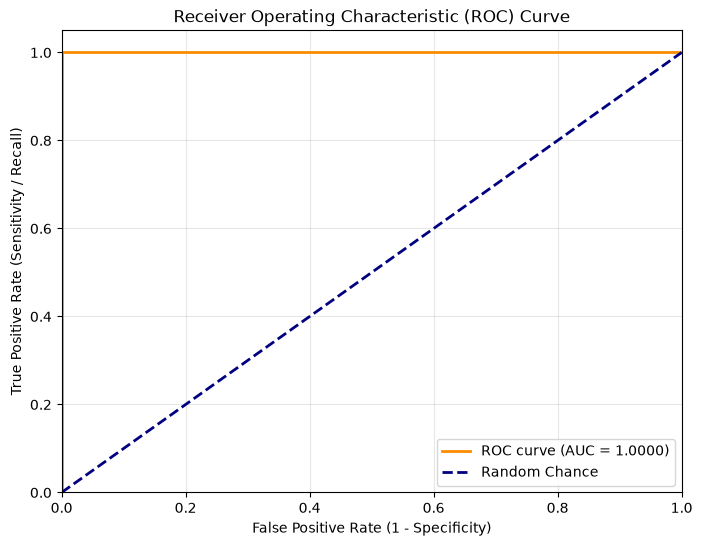

-----  Val  -----
Model F1 score: 1.0000
Model accuracy: 1.0000
[[6436    0]
 [   0   60]]



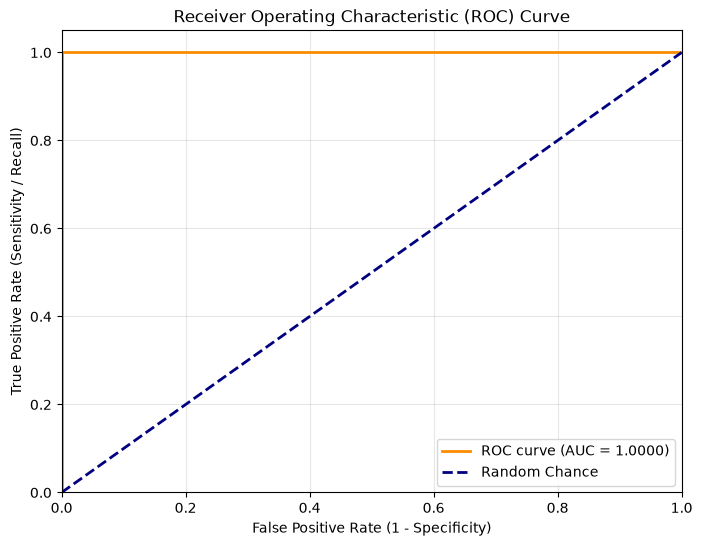

-----  Test  -----
Model F1 score: 1.0000
Model accuracy: 1.0000
[[2147    0]
 [   0   19]]

------------------------------------


------------------------------------
RF - gini_50
------------------------------------


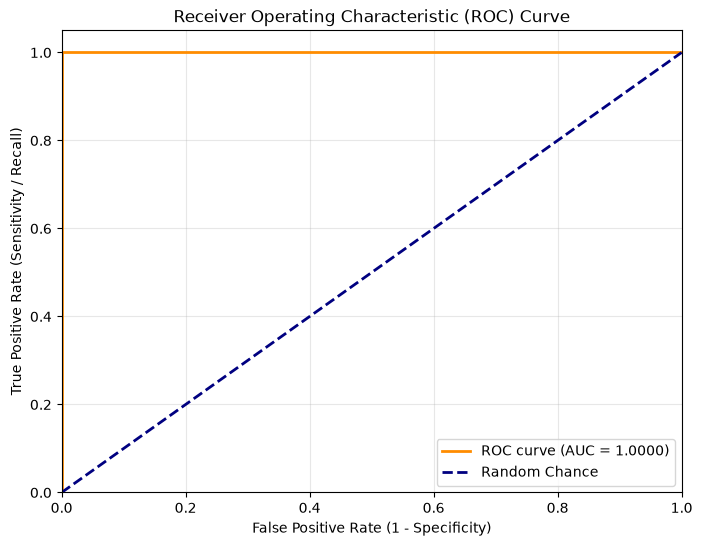

-----  Trainsm  -----
Model F1 score: 0.9998
Model accuracy: 0.9998
[[8580    3]
 [   0 8583]]



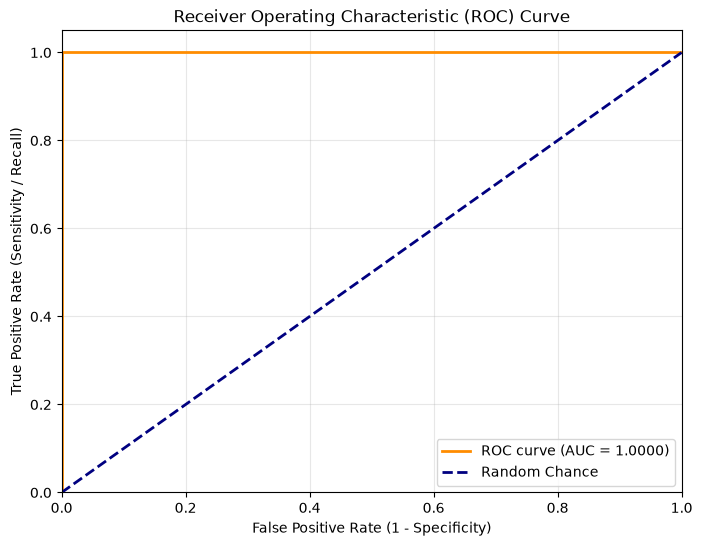

-----  Train  -----
Model F1 score: 0.9814
Model accuracy: 0.9997
[[8580    3]
 [   0   79]]



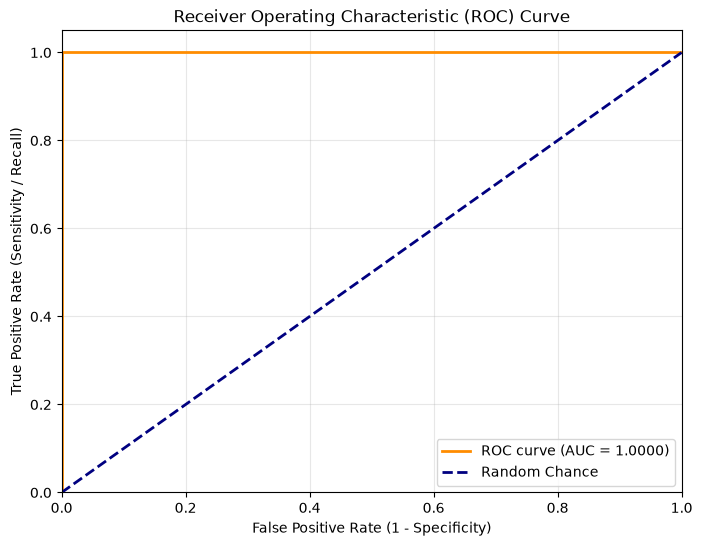

-----  Val  -----
Model F1 score: 0.9836
Model accuracy: 0.9997
[[6434    2]
 [   0   60]]



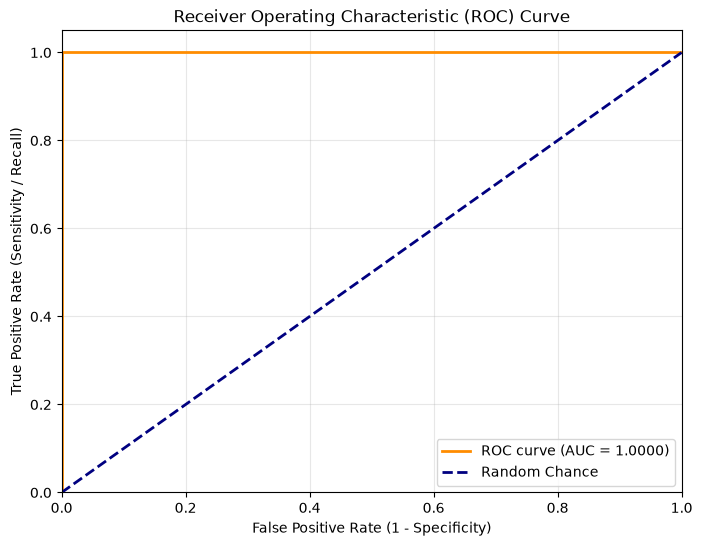

-----  Test  -----
Model F1 score: 0.9744
Model accuracy: 0.9995
[[2146    1]
 [   0   19]]

------------------------------------


------------------------------------
RF - gini_100
------------------------------------


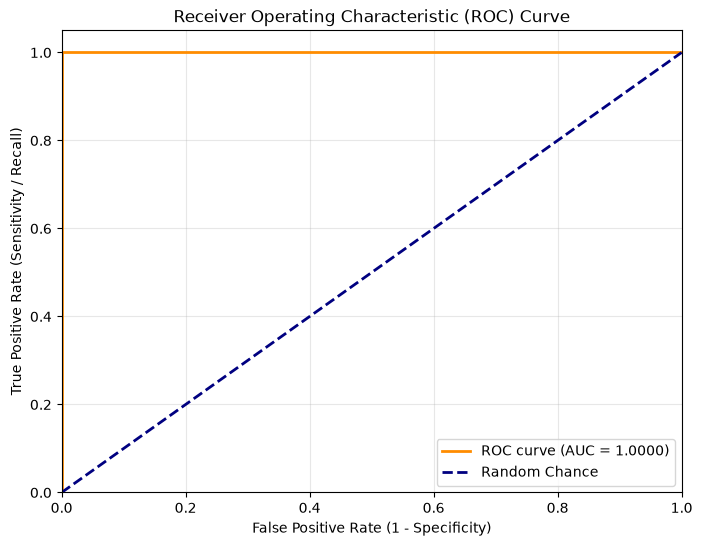

-----  Trainsm  -----
Model F1 score: 0.9999
Model accuracy: 0.9999
[[8581    2]
 [   0 8583]]



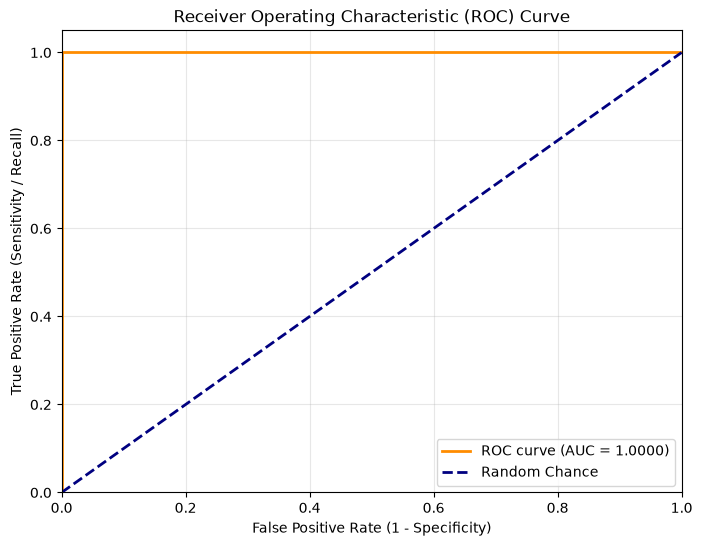

-----  Train  -----
Model F1 score: 0.9875
Model accuracy: 0.9998
[[8581    2]
 [   0   79]]



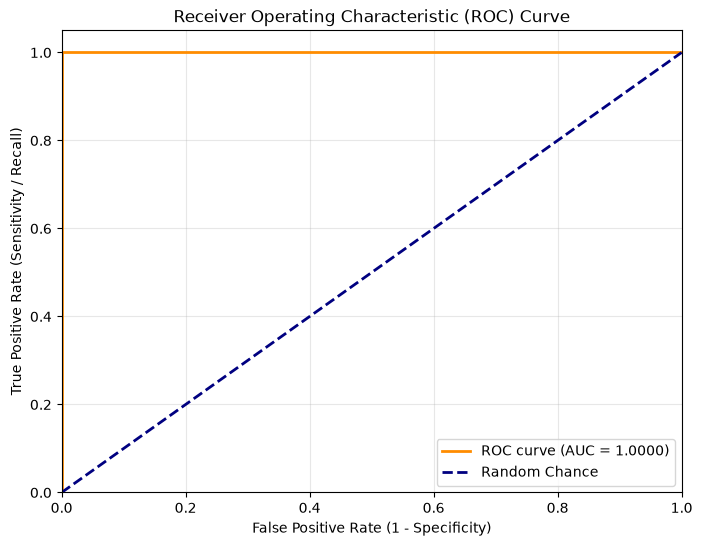

-----  Val  -----
Model F1 score: 0.9917
Model accuracy: 0.9998
[[6435    1]
 [   0   60]]



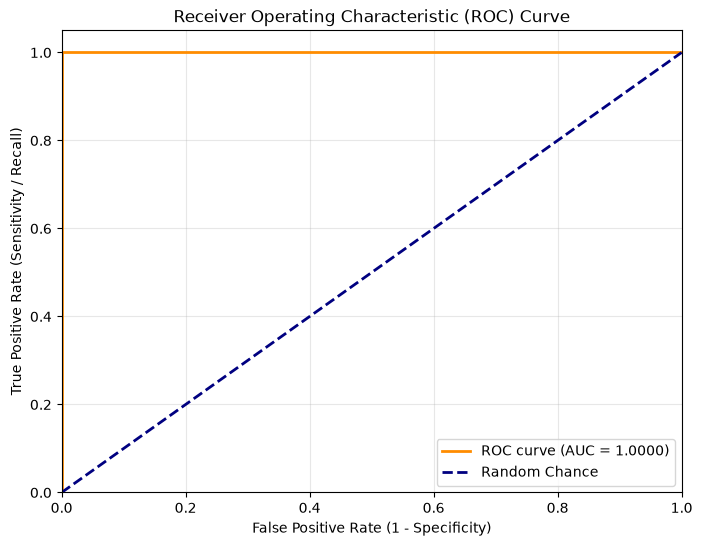

-----  Test  -----
Model F1 score: 0.9744
Model accuracy: 0.9995
[[2146    1]
 [   0   19]]

------------------------------------


------------------------------------
RF - gini_300
------------------------------------


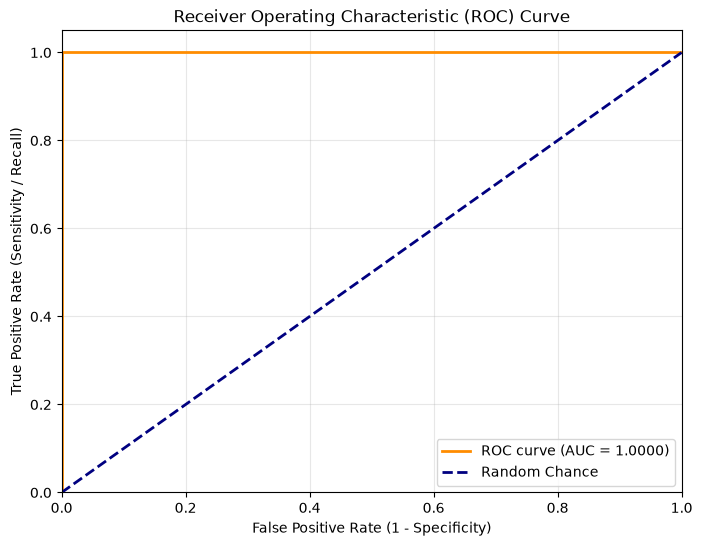

-----  Trainsm  -----
Model F1 score: 1.0000
Model accuracy: 1.0000
[[8583    0]
 [   0 8583]]



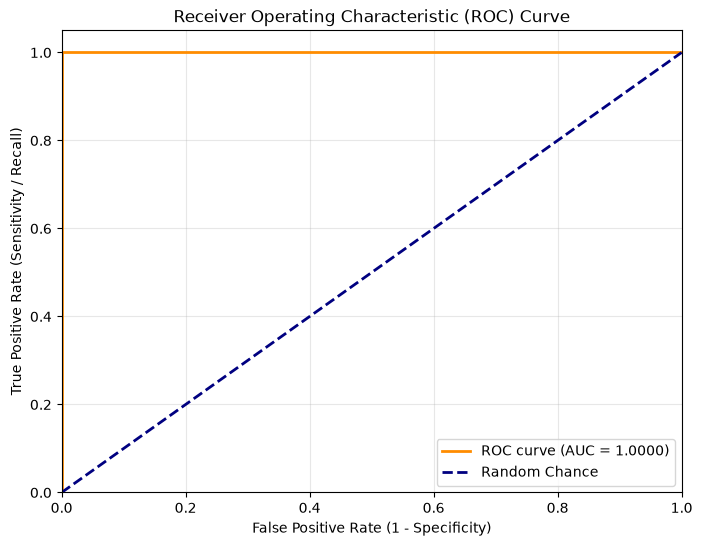

-----  Train  -----
Model F1 score: 1.0000
Model accuracy: 1.0000
[[8583    0]
 [   0   79]]



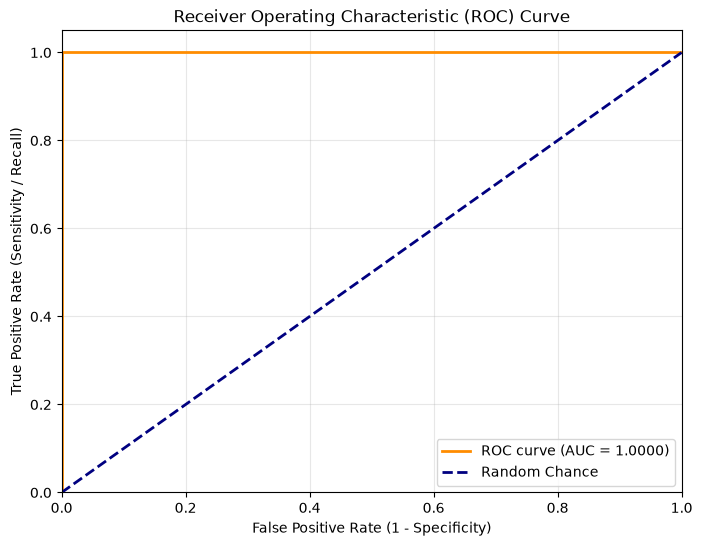

-----  Val  -----
Model F1 score: 1.0000
Model accuracy: 1.0000
[[6436    0]
 [   0   60]]



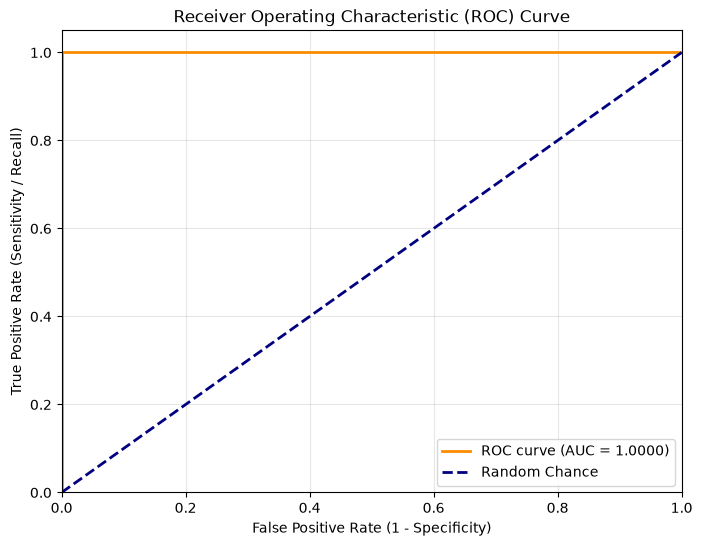

-----  Test  -----
Model F1 score: 1.0000
Model accuracy: 1.0000
[[2147    0]
 [   0   19]]

------------------------------------


------------------------------------
LogReg
------------------------------------


c:\Users\Hallen\anaconda3\envs\silv_env\Lib\site-packages\sklearn\linear_model\_logistic.py:1403: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', l1_ratio set to a float between 0 and 1 instead of penalty='elasticnet', and C=np.inf instead of penalty=None.
  warnings.warn(


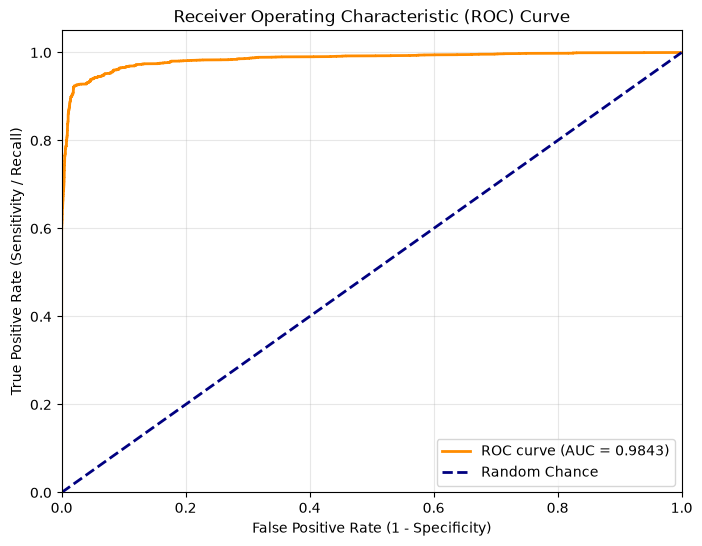

-----  Trainsm  -----
Model F1 score: 0.9471
Model accuracy: 0.9482
[[8308  275]
 [ 615 7968]]



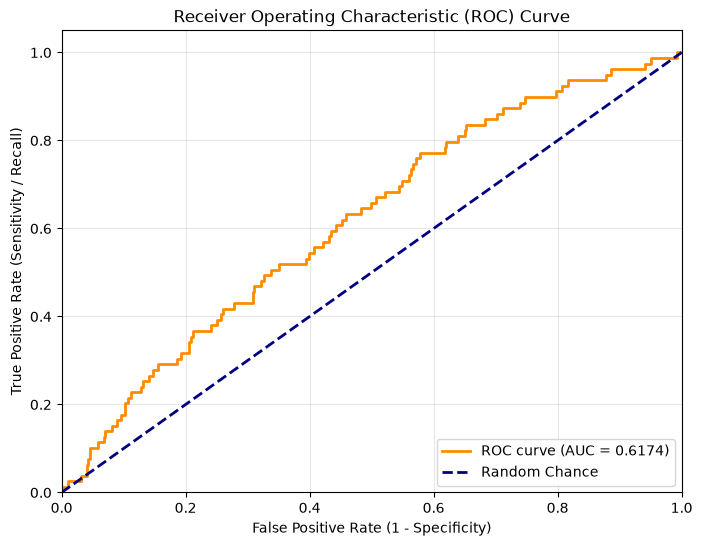

-----  Train  -----
Model F1 score: 0.0168
Model accuracy: 0.9595
[[8308  275]
 [  76    3]]



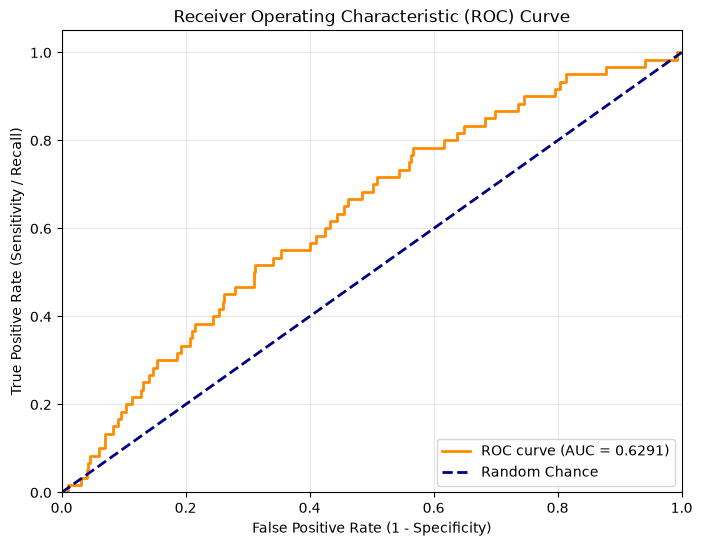

-----  Val  -----
Model F1 score: 0.0145
Model accuracy: 0.9583
[[6223  213]
 [  58    2]]



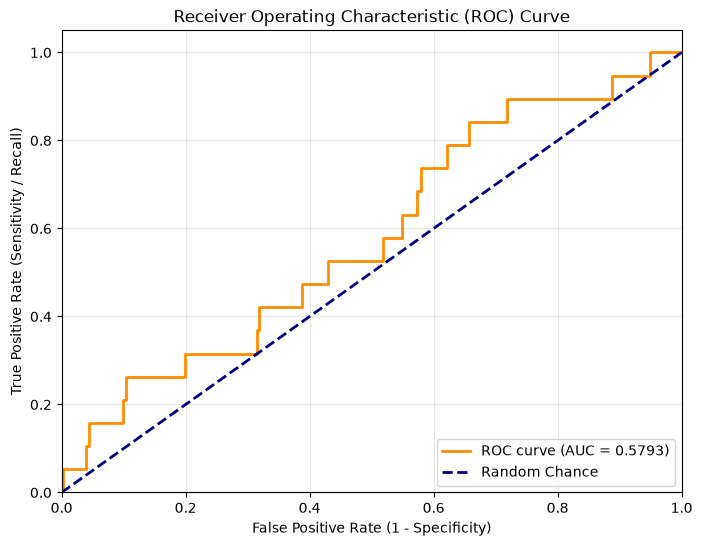

-----  Test  -----
Model F1 score: 0.0244
Model accuracy: 0.9631
[[2085   62]
 [  18    1]]

------------------------------------


------------------------------------
XGBoost - 
------------------------------------


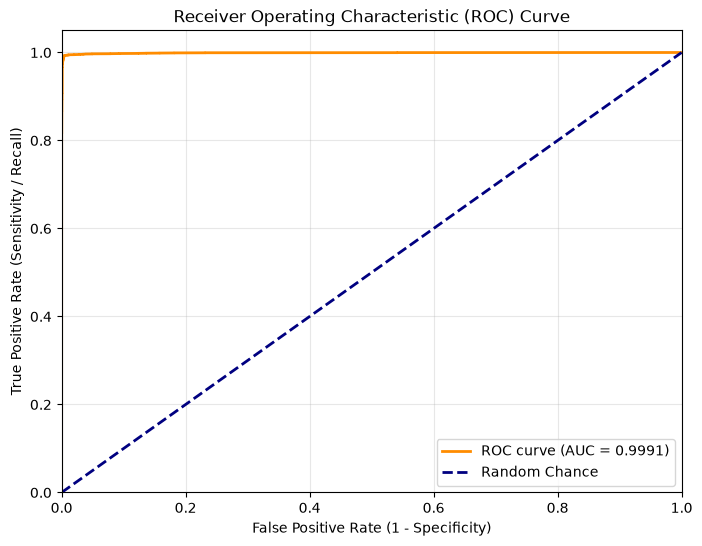

-----  Trainsm  -----
Model F1 score: 0.9916
Model accuracy: 0.9916
[[8488   95]
 [  50 8533]]



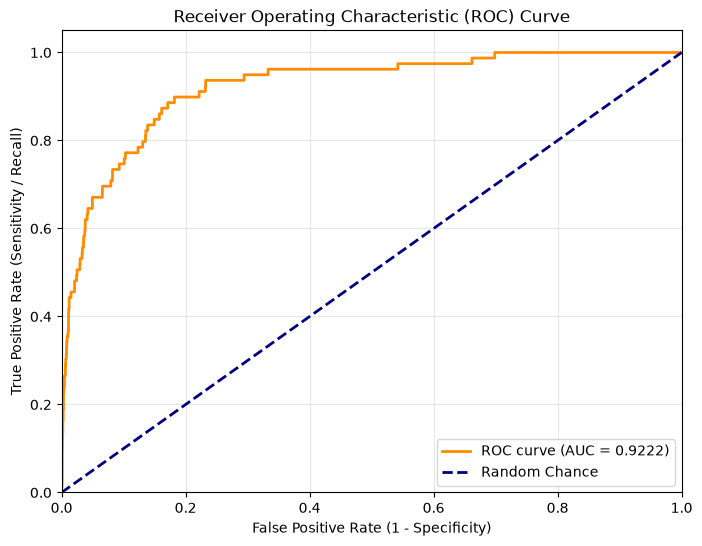

-----  Train  -----
Model F1 score: 0.2857
Model accuracy: 0.9833
[[8488   95]
 [  50   29]]



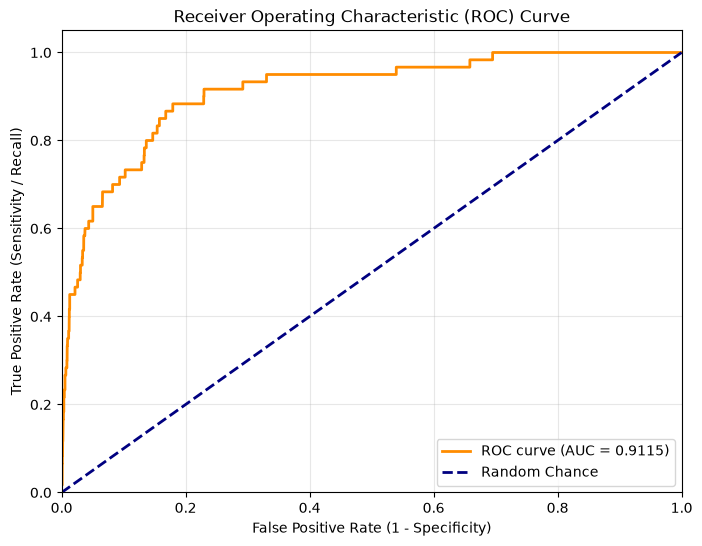

-----  Val  -----
Model F1 score: 0.2750
Model accuracy: 0.9821
[[6358   78]
 [  38   22]]



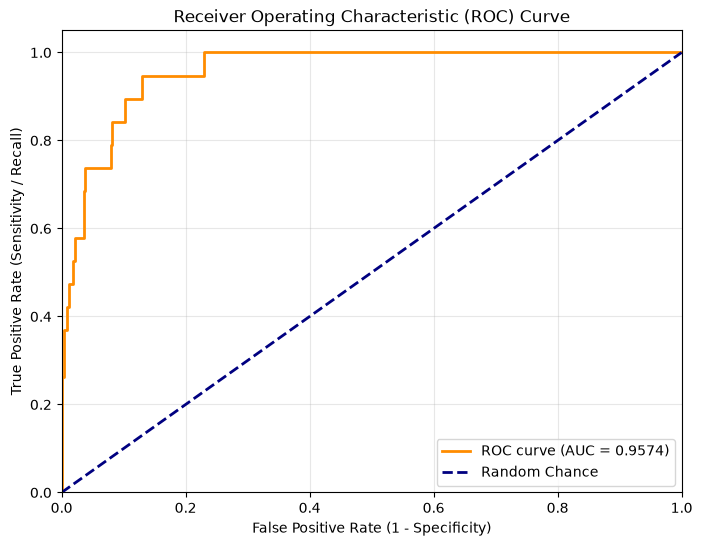

-----  Test  -----
Model F1 score: 0.3256
Model accuracy: 0.9866
[[2130   17]
 [  12    7]]

------------------------------------




In [1369]:
ds_list = [
    ("Trainsm", X_train_sm, y_train_sm),
    ("Train", X_train, y_train),
    ("Val", X_val, y_val),
    ("Test", X_test, y_test)
]

results = []

for exp in my_experiment_list:
    name = exp["name"]
    clf_class = exp["clf"]
    params = exp["params"]

    clf = clf_class(**params)
    clf.fit(X_train_sm, y_train_sm)

    exp_res = {
        "name": name
    }

    print("------------------------------------")
    print(name)
    print("------------------------------------")

    for ds_name, ds_x, ds_y in ds_list:
        ds_y_proba = clf.predict_proba(ds_x)[:, 1]
        ds_y_pred = np.where(ds_y_proba >= 0.4, 1, 0)
        

        f1s = f1_score(ds_y, ds_y_pred, pos_label= 1)
        acc = accuracy_score(ds_y, ds_y_pred)
        auc = plot_auc(ds_y, ds_y_proba)
        print("----- ", ds_name, " -----")
        print('Model F1 score: {0:0.4f}'. format(f1s))
        print('Model accuracy: {0:0.4f}'. format(acc))

        cm = confusion_matrix(ds_y, ds_y_pred)
        tn, fp, fn, tp = cm.ravel()

        exp_res[ds_name + "_f1sore"] = f1s
        exp_res[ds_name + "_acc"] = acc
        exp_res[ds_name + "_auc"] = auc
        exp_res[ds_name + "_tn"] = tn
        exp_res[ds_name + "_fp"] = fp
        exp_res[ds_name + "_fn"] = fn
        exp_res[ds_name + "_tp"] = tp

        print(cm)
        print()
    results.append(exp_res)
    print("------------------------------------")
    print()
    print()



In [1370]:
res_df = pd.DataFrame.from_records(results)
res_df = res_df.sort_values(by="Test_f1sore", ascending=False)
res_df

,name,Trainsm_f1sore,Trainsm_acc,Trainsm_auc,Trainsm_tn,Trainsm_fp,Trainsm_fn,Trainsm_tp,Train_f1sore,Train_acc,...,Val_fp,Val_fn,Val_tp,Test_f1sore,Test_acc,Test_auc,Test_tn,Test_fp,Test_fn,Test_tp
0,DT - gini,1.000000,1.000000,1.000000,8583,0,0,8583,1.000000,1.000000,...,0,0,60,1.000000,1.000000,1.000000,2147,0,0,19
1,DT - entropy,1.000000,1.000000,1.000000,8583,0,0,8583,1.000000,1.000000,...,0,0,60,1.000000,1.000000,1.000000,2147,0,0,19
4,RF - gini_300,1.000000,1.000000,1.000000,8583,0,0,8583,1.000000,1.000000,...,0,0,60,1.000000,1.000000,1.000000,2147,0,0,19
2,RF - gini_50,0.999825,0.999825,1.000000,8580,3,0,8583,0.981366,0.999654,...,2,0,60,0.974359,0.999538,1.000000,2146,1,0,19
3,RF - gini_100,0.999884,0.999883,1.000000,8581,2,0,8583,0.987500,0.999769,...,1,0,60,0.974359,0.999538,1.000000,2146,1,0,19
6,XGBoost -,0.991575,0.991553,0.999132,8488,95,50,8533,0.285714,0.983260,...,78,38,22,0.325581,0.986611,0.957395,2130,17,12,7
5,LogReg,0.947106,0.948153,0.984271,8308,275,615,7968,0.016807,0.959478,...,213,58,2,0.024390,0.963066,0.579315,2085,62,18,1


In [ ]:
import statsmodels.api as stm

model_stm = stm.Logit(y_train_sm, X_train_sm).fit()

print(model_stm.summary())

--------
--------

## 120 days train_test dataset

In [ ]:
Data_train_120_df["state_income_level"] = Data_train_120_df.customer_state.map(prov_income_map)

Data_train_120_df["state_income_level_high"] = (Data_train_120_df["state_income_level"] == "high").astype(int)
Data_train_120_df["state_income_level_mid"] = (Data_train_120_df["state_income_level"] == "mid").astype(int)
Data_train_120_df["state_income_level_low"] = (Data_train_120_df["state_income_level"] == "low").astype(int)

Data_train_120_df

In [ ]:

Data_train_120_df["high_review_score"] = (Data_train_120_df["review_score"]>= 4).astype(int)
Data_train_120_df["medium_review_score"] = ((Data_train_120_df["review_score"]< 4) & (Data_train_120_df["review_score"]>= 2)).astype(int)
Data_train_120_df["low_review_score"] = (Data_train_120_df["review_score"]< 2).astype(int)

Data_train_120_df


In [ ]:
Data_train_120_df["delay"] = (Data_train_120_df["dates_diff"]>0).astype(int)

Data_train_120_df["delay"]

In [ ]:
Data_train_120_df["high_payment_value"] = (Data_train_120_df["payment_value"]>172.73).astype(int)

Data_train_120_df["high_payment_value"]

In [ ]:
Data_train_120_df["expensive_freight"] = (Data_train_120_df["freight_to_price_ratio"]>0.15).astype(int)

Data_train_120_df["expensive_freight"]

In [ ]:
Data_train_120_df["high_freight_to_weight"] = (Data_train_120_df["freight_to_weight_ratio"]>0.20).astype(int)

Data_train_120_df["high_freight_to_weight"]

In [ ]:
Data_train_120_df["is_high_price"] = (Data_train_120_df["price"]>120.64).astype(int)

Data_train_120_df["is_high_price"]

In [ ]:
Data_train_120_df["beyond_one year"] = (Data_train_120_df["payment_installments"] > 12.0).astype(int)

Data_train_120_df["beyond_one year"]

In [ ]:
Data_train_120_df["multiple_payment_methods"] = (Data_train_120_df["payment_sequential"] > 2.0).astype(int)

Data_train_120_df["multiple_payment_methods"]

In [ ]:
Data_train_120_df["low_foto_count"] = (Data_train_120_df["product_photos_qty"] < 2).astype(int)

Data_train_120_df["low_foto_count"]

In [ ]:
target_features = ["order_status", "payment_type", "product_cat"]

col_trans = ColumnTransformer(
    transformers=[("cat", OneHotEncoder(sparse_output= False, drop="first", handle_unknown="ignore"), target_features)], remainder="passthrough"
)
col_trans.fit(Data_train_120_df)

In [ ]:
encoded_array = col_trans.transform(Data_train_120_df)

In [ ]:
encoded_120_df = pd.DataFrame(encoded_array, columns= col_trans.get_feature_names_out(Data_train_120_df.columns))

encoded_120_df

In [ ]:
encoded_120_df.columns = encoded_120_df.columns.str.replace('remainder__', '')

encoded_120_df

-----

## Test dataset

In [ ]:
Data_test_120_df

In [ ]:
Data_test_120_df["state_income_level"] = Data_test_120_df.customer_state.map(prov_income_map)

Data_test_120_df["state_income_level_high"] = (Data_test_120_df["state_income_level"] == "high").astype(int)
Data_test_120_df["state_income_level_mid"] = (Data_test_120_df["state_income_level"] == "mid").astype(int)
Data_test_120_df["state_income_level_low"] = (Data_test_120_df["state_income_level"] == "low").astype(int)

Data_test_120_df 

In [ ]:
Data_test_120_df["high_review_score"] = (Data_test_120_df["review_score"]>= 4).astype(int)
Data_test_120_df["medium_review_score"] = ((Data_test_120_df["review_score"]< 4) & (Data_test_120_df["review_score"]>= 2)).astype(int)
Data_test_120_df["low_review_score"] = (Data_test_120_df["review_score"]< 2).astype(int)

Data_test_120_df

In [ ]:
Data_test_120_df["delay"] = (Data_test_120_df["dates_diff"]>0).astype(int)

Data_test_120_df["delay"]

In [ ]:
Data_test_120_df["high_payment_value"] = (Data_test_120_df["payment_value"]>172.73).astype(int)

Data_test_120_df["high_payment_value"]

In [ ]:
Data_test_120_df["expensive_freight"] = (Data_test_120_df["freight_to_price_ratio"]>0.15).astype(int)

Data_test_120_df["expensive_freight"]

In [ ]:
Data_test_120_df["high_freight_to_weight"] = (Data_test_120_df["freight_to_weight_ratio"]>0.20).astype(int)

Data_test_120_df["high_freight_to_weight"]

In [ ]:
Data_test_120_df["is_high_price"] = (Data_test_120_df["price"]>120.64).astype(int)

Data_test_120_df["is_high_price"] 

In [ ]:
Data_test_120_df["beyond_one year"] = (Data_test_120_df["payment_installments"] > 12.0).astype(int)

Data_test_120_df["beyond_one year"]

In [ ]:
Data_test_120_df["multiple_payment_methods"] = (Data_test_120_df["payment_sequential"] > 2.0).astype(int)

Data_test_120_df["multiple_payment_methods"]

In [ ]:
Data_test_120_df["low_foto_count"] = (Data_test_120_df["product_photos_qty"] < 2).astype(int)

Data_test_120_df["low_foto_count"]

In [ ]:
encoded_array_test = col_trans.transform(Data_test_120_df)

In [ ]:
encoded_120_test_df = pd.DataFrame(encoded_array_test, columns= col_trans.get_feature_names_out(Data_test_120_df.columns))

encoded_120_test_df

In [ ]:
encoded_120_test_df.columns = encoded_120_test_df.columns.str.replace('remainder__', '')

encoded_120_test_df

-----

## Train test split

In [ ]:
X_train = encoded_120_test_df.drop(columns = ['churn_120', "customer_unique_id",  "customer_city", "customer_state", "payment_sequential", "payment_installments",	"state_income_level", "price", "freight_to_price_ratio", "freight_to_weight_ratio", "product_photos_qty", "payment_value", "dates_diff",	"review_score"])

y_train = encoded_120_test_df['churn_120'].fillna(0).astype(int)

In [ ]:
X_valtest = encoded_120_test_df.drop(columns = ['churn_120', "customer_unique_id", "customer_city", "customer_state", "payment_sequential", "payment_installments",	"state_income_level", "price", "freight_to_price_ratio", "freight_to_weight_ratio", "product_photos_qty", "payment_value", "dates_diff",	"review_score"])

y_valtest = encoded_120_test_df['churn_120'].fillna(0).astype(int)

In [ ]:
from sklearn.model_selection import train_test_split

X_val, X_test, y_val, y_test  =  train_test_split(X_valtest, y_valtest, random_state = 42)

In [ ]:
print(X_train.shape)
print(X_valtest.shape)

In [ ]:
X_train = X_train.astype(int)

X_val = X_val.astype(int)

X_test = X_test.astype(int)

In [ ]:
plt.bar(y_train.value_counts().index, y_train.value_counts().values, color=['skyblue','pink'])
plt.xticks([0,1], ["Churned", "Repurchase"])
plt.ylabel("Count")
plt.title("Churn distribution")
plt.show()

In [ ]:
X_valtest.columns

In [ ]:
from imblearn.over_sampling import SMOTE

smote = SMOTE(sampling_strategy="minority", random_state=42)
X_train_sm, y_train_sm = smote.fit_resample(X_train, y_train)

plt.bar(y_train_sm.value_counts().index, y_train_sm.value_counts().values, 
        color=["skyblue","pink"])
plt.xticks([0,1], ["Churned", "Repurchased"])
plt.ylabel("Count")
plt.title(" Churn Class Distribution AFTER SMOTE")
plt.show()

In [ ]:
ds_list = [
    ("Trainsm", X_train_sm, y_train_sm),
    ("Train", X_train, y_train),
    ("Val", X_val, y_val),
    ("Test", X_test, y_test)
]

results = []

for exp in my_experiment_list:
    name = exp["name"]
    clf_class = exp["clf"]
    params = exp["params"]

    clf = clf_class(**params)
    clf.fit(X_train_sm, y_train_sm)

    exp_res = {
        "name": name
    }

    print("------------------------------------")
    print(name)
    print("------------------------------------")

    for ds_name, ds_x, ds_y in ds_list:
        ds_y_proba = clf.predict_proba(ds_x)[:, 0]
        ds_y_pred = np.where(ds_y_proba >= 0.4, 0, 1)
        

        f1s = f1_score(ds_y, ds_y_pred, pos_label= 1)
        acc = accuracy_score(ds_y, ds_y_pred)
        auc = plot_auc(ds_y, ds_y_proba)
        print("----- ", ds_name, " -----")
        print('Model F1 score: {0:0.4f}'. format(f1s))
        print('Model accuracy: {0:0.4f}'. format(acc))

        cm = confusion_matrix(ds_y, ds_y_pred)
        tn, fp, fn, tp = cm.ravel()

        exp_res[ds_name + "_f1sore"] = f1s
        exp_res[ds_name + "_acc"] = acc
        exp_res[ds_name + "_auc"] = auc
        exp_res[ds_name + "_tn"] = tn
        exp_res[ds_name + "_fp"] = fp
        exp_res[ds_name + "_fn"] = fn
        exp_res[ds_name + "_tp"] = tp

        print(cm)
        print()
    results.append(exp_res)
    print("------------------------------------")
    print()
    print()



In [ ]:
res_df = pd.DataFrame.from_records(results)
res_df = res_df.sort_values(by="Test_f1sore", ascending=False)
res_df

In [ ]:
import cvxopt as cvxopt 
import statsmodels.api as stm

model_stm = stm.Logit(y_train_sm, X_train_sm).fit_regularized(method='l1', maxiter=500, alpha=10.0,)

print(model_stm.summary())

----
----

## 150 days

## 150 days train_test dataset

In [ ]:
Data_train_150_df["state_income_level"] = Data_train_150_df.customer_state.map(prov_income_map)

Data_train_150_df["state_income_level_high"] = (Data_train_150_df["state_income_level"] == "high").astype(int)
Data_train_150_df["state_income_level_mid"] = (Data_train_150_df["state_income_level"] == "mid").astype(int)
Data_train_150_df["state_income_level_low"] = (Data_train_150_df["state_income_level"] == "low").astype(int)

Data_train_150_df

In [ ]:
Data_train_150_df["high_review_score"] = (Data_train_150_df["review_score"]>= 4).astype(int)
Data_train_150_df["medium_review_score"] = ((Data_train_150_df["review_score"]< 4) & (Data_train_150_df["review_score"]>= 2)).astype(int)
Data_train_150_df["low_review_score"] = (Data_train_150_df["review_score"]< 2).astype(int)

Data_train_150_df

In [ ]:
Data_train_150_df["delay"] = (Data_train_150_df["dates_diff"]>0).astype(int)

Data_train_150_df["delay"]

In [ ]:
Data_train_150_df["high_payment_value"] = (Data_train_150_df["payment_value"]>172.73).astype(int)

Data_train_150_df["high_payment_value"]

In [ ]:
Data_train_150_df["expensive_freight"] = (Data_train_150_df["freight_to_weight_ratio"]>0.15).astype(int)

Data_train_150_df["expensive_freight"]

In [ ]:
Data_train_150_df["high_freight_to_weight"] = (Data_train_150_df["freight_to_weight_ratio"]>0.20).astype(int)

Data_train_150_df["high_freight_to_weight"]

In [ ]:
Data_train_150_df["is_high_price"] = (Data_train_150_df["price"]>120.64).astype(int)

Data_train_150_df["is_high_price"]

In [ ]:
Data_train_150_df["beyond_one year"] = (Data_train_150_df["payment_installments"] > 12.0).astype(int)

Data_train_150_df["beyond_one year"]

In [ ]:
Data_train_150_df["multiple_payment_methods"] = (Data_train_150_df["payment_sequential"] > 2.0).astype(int)

Data_train_150_df["multiple_payment_methods"]

In [ ]:
Data_train_150_df["low_foto_count"] = (Data_train_150_df["product_photos_qty"] < 2).astype(int)

Data_train_150_df["low_foto_count"]

In [ ]:
target_features = ["order_status", "payment_type", "product_cat"]

col_trans = ColumnTransformer(
    transformers=[("cat", OneHotEncoder(sparse_output= False, drop= "first", handle_unknown="ignore"), target_features)], remainder="passthrough"
)
col_trans.fit(Data_train_150_df)

In [ ]:
encoded_array = col_trans.transform(Data_train_150_df)

In [ ]:
encoded_150_df = pd.DataFrame(encoded_array, columns= col_trans.get_feature_names_out(Data_train_150_df.columns))

encoded_150_df

In [ ]:
encoded_150_df.columns = encoded_150_df.columns.str.replace('remainder__', '')

encoded_150_df

----

## Test dataset

In [ ]:
Data_test_150_df

In [ ]:
Data_test_150_df["state_income_level"] = Data_test_150_df.customer_state.map(prov_income_map)

Data_test_150_df["state_income_level_high"] = (Data_test_150_df["state_income_level"] == "high").astype(int)
Data_test_150_df["state_income_level_mid"] = (Data_test_150_df["state_income_level"] == "mid").astype(int)
Data_test_150_df["state_income_level_low"] = (Data_test_150_df["state_income_level"] == "low").astype(int)

Data_test_150_df 

In [ ]:
Data_test_150_df["high_review_score"] = (Data_test_150_df["review_score"]>= 4).astype(int)
Data_test_150_df["medium_review_score"] = ((Data_test_150_df["review_score"]< 4) & (Data_test_150_df["review_score"]>= 2)).astype(int)
Data_test_150_df["low_review_score"] = (Data_test_150_df["review_score"]< 2).astype(int)

Data_test_150_df

In [ ]:
Data_test_150_df["delay"] = (Data_test_150_df["dates_diff"]>0).astype(int)

Data_test_150_df["delay"]

In [ ]:
Data_test_150_df["high_payment_value"] = (Data_test_150_df["payment_value"]>172.73).astype(int)

Data_test_150_df["high_payment_value"]

In [ ]:
Data_test_150_df["expensive_freight"] = (Data_test_150_df["freight_to_weight_ratio"]>20.03).astype(int)

Data_test_150_df["expensive_freight"]

In [ ]:
Data_test_150_df["high_freight_to_weight"] = (Data_test_150_df["freight_to_weight_ratio"]>0.20).astype(int)

Data_test_150_df["high_freight_to_weight"]

In [ ]:
Data_test_150_df["is_high_price"] = (Data_test_150_df["price"]>120.64).astype(int)

Data_test_150_df["is_high_price"]

In [ ]:
Data_test_150_df["beyond_one year"] = (Data_test_150_df["payment_installments"] > 12.0).astype(int)

Data_test_150_df["beyond_one year"]

In [ ]:
Data_test_150_df["multiple_payment_methods"] = (Data_test_150_df["payment_sequential"] > 2.0).astype(int)

Data_test_150_df["multiple_payment_methods"]

In [ ]:
Data_test_150_df["low_foto_count"] = (Data_test_150_df["product_photos_qty"] < 2).astype(int)

Data_test_150_df["low_foto_count"]

In [ ]:
encoded_array_test = col_trans.transform(Data_test_150_df)

In [ ]:
encoded_150_test_df = pd.DataFrame(encoded_array_test, columns= col_trans.get_feature_names_out(Data_test_150_df.columns))

encoded_150_test_df

In [ ]:
encoded_150_test_df.columns = encoded_150_test_df.columns.str.replace('remainder__', '')

encoded_150_test_df

-----

## Train test split

In [ ]:
X_train = encoded_150_df.drop(columns = ['churn_150', "customer_unique_id", "customer_city", "customer_state",	"payment_sequential", "payment_installments",	"state_income_level", "price", "freight_to_price_ratio", "freight_to_weight_ratio", "product_photos_qty", "payment_value", "dates_diff",	"review_score" ])

y_train = encoded_150_df['churn_150'].fillna(0).astype(int)

In [ ]:
X_valtest = encoded_150_test_df.drop(columns = ['churn_150', "customer_unique_id", "customer_city", "customer_state",	"payment_sequential", "payment_installments",	"state_income_level", "price", "freight_to_price_ratio", "freight_to_weight_ratio", "product_photos_qty", "payment_value", "dates_diff",	"review_score"])

y_valtest = encoded_150_test_df['churn_150'].fillna(0).astype(int)

In [ ]:
X_val, X_test, y_val, y_test  =  train_test_split(X_valtest, y_valtest, random_state = 42)

In [ ]:
print(X_train.shape)
print(X_valtest.shape)

In [ ]:
X_train = X_train.astype(int)

X_val = X_val.astype(int)

X_test = X_test.astype(int)

In [ ]:
plt.bar(y_train.value_counts().index, y_train.value_counts().values, color=['skyblue','pink'])
plt.xticks([0,1], ["Churned", "Repurchased"])
plt.ylabel("Count")
plt.title("Churn distribution")
plt.show()

In [ ]:
from imblearn.over_sampling import SMOTE

smote = SMOTE(sampling_strategy="minority", random_state=42)
X_train_sm, y_train_sm = smote.fit_resample(X_train, y_train)

plt.bar(y_train_sm.value_counts().index, y_train_sm.value_counts().values, 
        color=["skyblue","pink"])
plt.xticks([0,1], ["Churned", "Repurchased"])
plt.ylabel("Count")
plt.title(" Churn Class Distribution AFTER SMOTE")
plt.show()

In [ ]:
ds_list = [
    ("Trainsm", X_train_sm, y_train_sm),
    ("Train", X_train, y_train),
    ("Val", X_val, y_val),
    ("Test", X_test, y_test)
]

results = []

for exp in my_experiment_list:
    name = exp["name"]
    clf_class = exp["clf"]
    params = exp["params"]

    clf = clf_class(**params)
    clf.fit(X_train_sm, y_train_sm)

    exp_res = {
        "name": name
    }

    print("------------------------------------")
    print(name)
    print("------------------------------------")

    for ds_name, ds_x, ds_y in ds_list:
        ds_y_proba = clf.predict_proba(ds_x)[:, 0]
        ds_y_pred = np.where(ds_y_proba >= 0.4, 0, 1)
        

        f1s = f1_score(ds_y, ds_y_pred, pos_label= 1)
        acc = accuracy_score(ds_y, ds_y_pred)
        auc = plot_auc(ds_y, ds_y_proba)
        print("----- ", ds_name, " -----")
        print('Model F1 score: {0:0.4f}'. format(f1s))
        print('Model accuracy: {0:0.4f}'. format(acc))

        cm = confusion_matrix(ds_y, ds_y_pred)
        tn, fp, fn, tp = cm.ravel()

        exp_res[ds_name + "_f1sore"] = f1s
        exp_res[ds_name + "_acc"] = acc
        exp_res[ds_name + "_auc"] = auc
        exp_res[ds_name + "_tn"] = tn
        exp_res[ds_name + "_fp"] = fp
        exp_res[ds_name + "_fn"] = fn
        exp_res[ds_name + "_tp"] = tp

        print(cm)
        print()
    results.append(exp_res)
    print("------------------------------------")
    print()
    print()



In [ ]:
res_df = pd.DataFrame.from_records(results)
res_df = res_df.sort_values(by="Test_f1sore", ascending=False)
res_df

In [ ]:
import statsmodels.api as stm

model_stm = stm.Logit(y_train_sm, X_train_sm).fit()

print(model_stm.summary())

------
------